In [7]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder

DATA_PATH = 'D:/pycharmProject/TimeSequences/data/'
OUTPUT_PATH = DATA_PATH

# 加载数据
def load_data():
    train = pd.read_csv(DATA_PATH + 'train.csv', parse_dates=['date'])
    test = pd.read_csv(DATA_PATH + 'test.csv', parse_dates=['date'])
    holidays = pd.read_csv(DATA_PATH + 'holidays_events.csv', parse_dates=['date'])
    oil = pd.read_csv(DATA_PATH + 'oil.csv', parse_dates=['date'])
    stores = pd.read_csv(DATA_PATH + 'stores.csv')
    transactions = pd.read_csv(DATA_PATH + 'transactions.csv', parse_dates=['date'])
    return train, test, holidays, oil, stores, transactions

# 特征工程
def create_date_features(df):
    df['day'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype('int')
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    df['quarter'] = df['date'].dt.quarter
    return df

def create_lag_features(df, lags=[1, 7, 14, 28]):
    for lag in lags:
        df[f'sales_lag_{lag}'] = df.groupby(['store_nbr', 'family'])['sales'].shift(lag)
    return df

def create_rolling_features(df, windows=[7, 14, 28]):
    for window in windows:
        df[f'sales_roll_mean_{window}'] = (
            df.groupby(['store_nbr', 'family'])['sales']
            .shift(1)
            .rolling(window=window, min_periods=1)
            .mean()
        )
        df[f'sales_roll_mean_{window}'] = df.groupby(['store_nbr', 'family'])[f'sales_roll_mean_{window}'].ffill()
    return df


In [8]:
#合并外部数据
def merge_features(train, test, holidays, oil, stores, transactions):
    oil = oil.rename(columns={'dcoilwtico': 'oil_price'})
    test['sales'] = np.nan
    full_data = pd.concat([train, test], ignore_index=True)

    full_data = pd.merge(full_data, oil, on='date', how='left')
    national_holidays = holidays[holidays['locale'] == 'National'][['date', 'type']].rename(columns={'type': 'holiday_type'})
    full_data = pd.merge(full_data, national_holidays, on='date', how='left')
    full_data = pd.merge(full_data, stores, on='store_nbr', how='left')
    transactions = transactions.rename(columns={'transactions': 'daily_transactions'})
    full_data = pd.merge(full_data, transactions, on=['date', 'store_nbr'], how='left')

    full_data['oil_price'] = full_data['oil_price'].ffill().bfill()
    full_data['holiday_type'] = full_data['holiday_type'].fillna('No_Holiday')
    full_data['daily_transactions'] = full_data['daily_transactions'].fillna(0)

    full_data = full_data.sort_values(by=['store_nbr', 'family', 'date']).reset_index(drop=True)
    return full_data



Training until validation scores don't improve for 200 rounds
[500]	training's rmse: 0.372296	valid_1's rmse: 0.377313
[1000]	training's rmse: 0.360083	valid_1's rmse: 0.373947
[1500]	training's rmse: 0.35393	valid_1's rmse: 0.372014
[2000]	training's rmse: 0.349839	valid_1's rmse: 0.370829
[2500]	training's rmse: 0.346226	valid_1's rmse: 0.369889
[3000]	training's rmse: 0.343518	valid_1's rmse: 0.369288
[3500]	training's rmse: 0.341104	valid_1's rmse: 0.36874
[4000]	training's rmse: 0.339009	valid_1's rmse: 0.368334
[4500]	training's rmse: 0.337029	valid_1's rmse: 0.367949
[5000]	training's rmse: 0.335202	valid_1's rmse: 0.367701
Did not meet early stopping. Best iteration is:
[5000]	training's rmse: 0.335202	valid_1's rmse: 0.367701
Validation RMSLE: 0.3677

 预测文件已生成：final_submission.csv


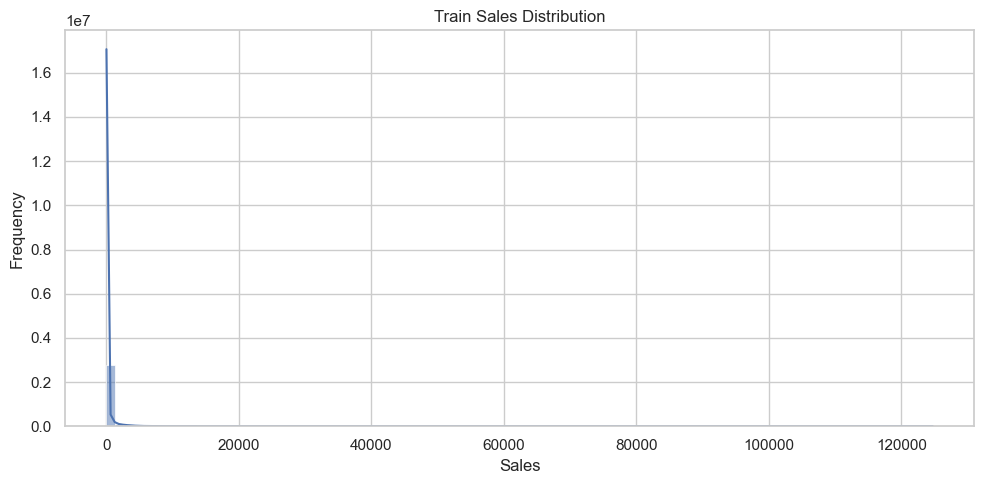

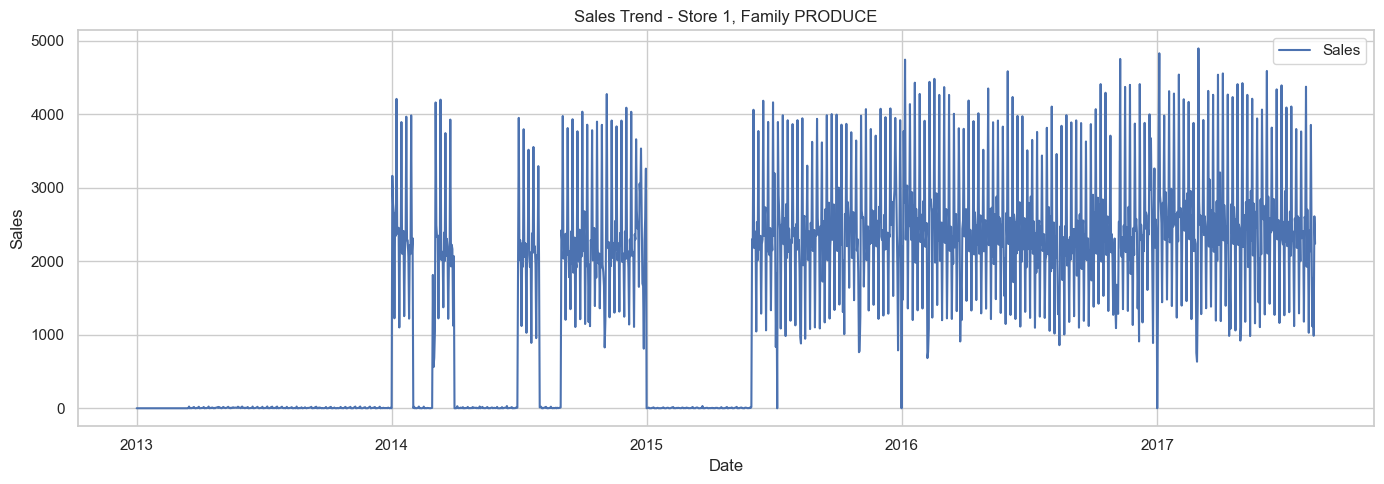

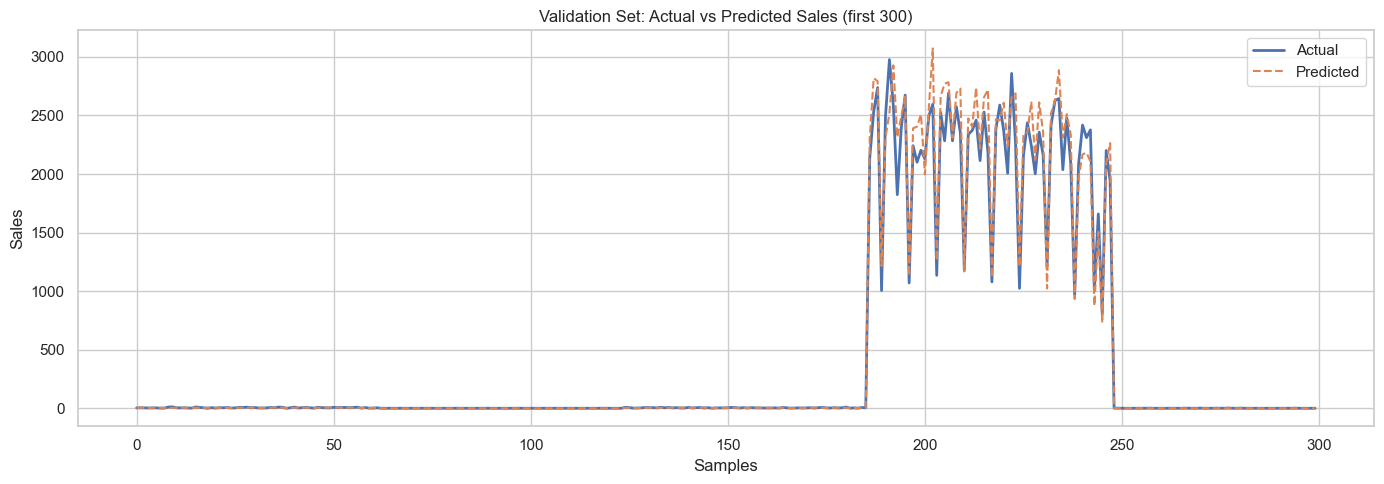

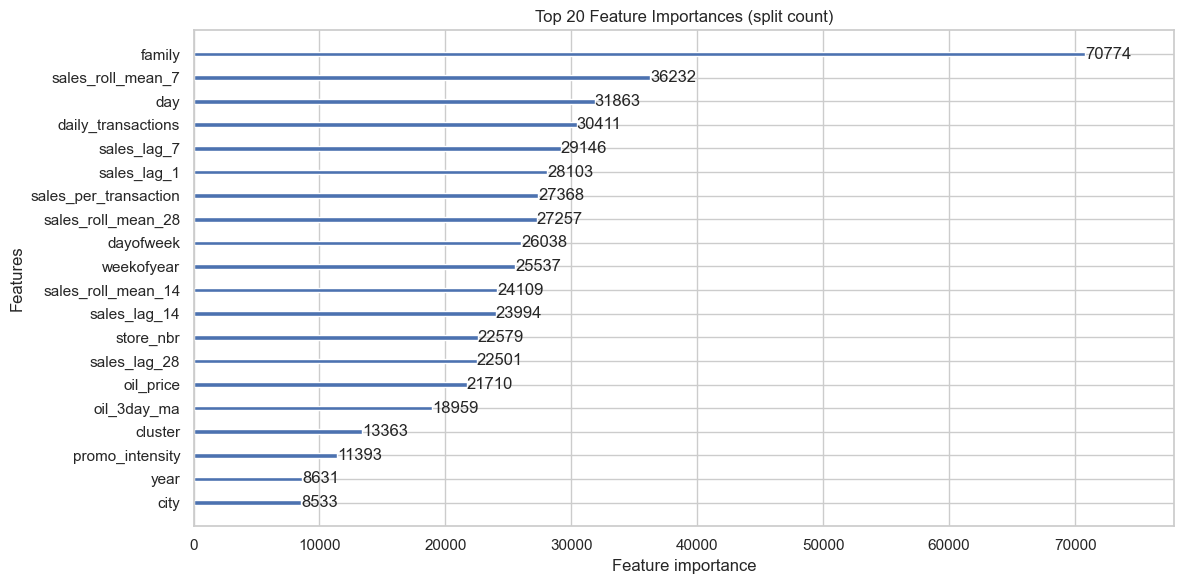

In [9]:
#主流程 
if __name__ == "__main__":
    train, test, holidays, oil, stores, transactions = load_data()
    full_data = merge_features(train, test, holidays, oil, stores, transactions)

    full_data = create_date_features(full_data)
    full_data = create_lag_features(full_data)
    full_data = create_rolling_features(full_data)

    full_data['sales_per_transaction'] = (
        full_data.groupby(['store_nbr', 'family'])['sales'].shift(1)
        / (full_data['daily_transactions'] + 1e-5)
    )
    full_data['promo_intensity'] = full_data['onpromotion'] / full_data.groupby(['store_nbr', 'family'])['onpromotion'].transform('mean')
    full_data['oil_3day_ma'] = full_data['oil_price'].rolling(3, min_periods=1).mean().ffill()

    for col in ['family', 'holiday_type', 'city', 'state']:
        full_data[col] = LabelEncoder().fit_transform(full_data[col])

    train = full_data[~full_data['sales'].isna()]
    test = full_data[full_data['sales'].isna()]

    features = [
        'store_nbr', 'family', 'onpromotion', 'day', 'weekofyear', 'month', 'year',
        'dayofweek', 'is_weekend', 'is_month_start', 'is_month_end', 'quarter',
        'oil_price', 'oil_3day_ma', 'holiday_type', 'cluster', 'city', 'state',
        'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
        'sales_roll_mean_7', 'sales_roll_mean_14', 'sales_roll_mean_28',
        'sales_per_transaction', 'promo_intensity', 'daily_transactions']

    X_train = train[train['date'] < '2017-06-15'][features]
    y_train = train[train['date'] < '2017-06-15']['sales']
    X_valid = train[train['date'] >= '2017-06-15'][features]
    y_valid = train[train['date'] >= '2017-06-15']['sales']

    y_train_log = np.log1p(y_train)
    y_valid_log = np.log1p(y_valid)

    train_data = lgb.Dataset(X_train, label=y_train_log, categorical_feature=['family', 'holiday_type'])
    valid_data = lgb.Dataset(X_valid, label=y_valid_log, categorical_feature=['family', 'holiday_type'])

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'learning_rate': 0.02,
        'num_leaves': 128,
        'max_depth': 7,
        'feature_fraction': 0.8,
        'bagging_freq': 5,
        'verbosity': -1,
        'seed': 42
    }

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data, valid_data],
        num_boost_round=5000,
        callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(500)]
    )

    y_pred = np.expm1(model.predict(X_valid))
    print(f'Validation RMSLE: {np.sqrt(mean_squared_log_error(y_valid, y_pred)):.4f}')

    test_pred = np.expm1(model.predict(test[features]))
    submission = pd.DataFrame({
        'id': test['id'],
        'unit_sales': np.maximum(0, test_pred)
    })
    submission.to_csv(OUTPUT_PATH + 'final_submission.csv', index=False)
    print("\n 预测文件已生成：final_submission.csv")

    # 可视化分析 
    sns.set(style="whitegrid")

    # 1. 销售分布
    plt.figure(figsize=(10, 5))
    sns.histplot(train['sales'], bins=100, kde=True)
    plt.title("Train Sales Distribution")
    plt.xlabel("Sales")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # 2. 某门店某商品类别趋势
    example_store = 1
    example_family = 'PRODUCE'
    raw_train = pd.read_csv(DATA_PATH + 'train.csv', parse_dates=['date'])
    example_df = raw_train[(raw_train['store_nbr'] == example_store) & (raw_train['family'] == example_family)]

    plt.figure(figsize=(14, 5))
    plt.plot(example_df['date'], example_df['sales'], label='Sales')
    plt.title(f"Sales Trend - Store {example_store}, Family {example_family}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3. 验证集预测 vs 实际
    plt.figure(figsize=(14, 5))
    plt.plot(y_valid.values[:300], label='Actual', linewidth=2)
    plt.plot(y_pred[:300], label='Predicted', linestyle='--')
    plt.title("Validation Set: Actual vs Predicted Sales (first 300)")
    plt.xlabel("Samples")
    plt.ylabel("Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4. 特征重要性
    lgb.plot_importance(model, max_num_features=20, importance_type='split', figsize=(12, 6))
    plt.title("Top 20 Feature Importances (split count)")
    plt.tight_layout()
    plt.show()
